In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/04 15:51:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/04 15:51:01 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/12/04 15:51:01 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [9]:
path_to_release_folder = "../../../data/25.06/"
path_to_intermediate_data_folder = "../../../data/intermediate_files/"

sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = path_to_release_folder + "output/evidence/sourceId=chembl"
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)

chembl_evidence.show(1)

l2g_full = session.spark.read.parquet(path_to_intermediate_data_folder + "l2g_full_for_enrichment/")
l2g_full.count()

l2g_full.show(1)


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

In [ ]:
new_chembl = session.spark.read.parquet(path_to_intermediate_data_folder + "chembl_evidence_with_rusina_et_al_pharmprj")


# Run and safe the data


In [ ]:
import pandas as pd

all_enrich = []

for year in range(2008, 2026):
    evidence = chemblDrugEnrichment.to_disease_target_evidence(
        table_with_score=l2g_full.filter(f.col("year") <= year).drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1,
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        # chembl_orig=new_chembl,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )
    enrich["datasource"] = str(year)
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)


In [17]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)


In [7]:
combined_enrich.iloc[0, :]


clinicalPhase                       2+
odds_ratio                    1.974747
p_value                            1.0
ci_low                        0.252737
ci_high                       15.42959
Relative success              1.088613
ci_rs_low                     0.903004
ci_rs_high                    1.312374
rs_p_value                    0.373343
no_evid-low_clinphase             6162
no_evid-high_clinphase           31204
yes_evid-low_clinphase               1
yes_evid-high_clinphase             10
total_indirect_assoc               897
datasource                        2008
drugsource                 full_chembl
Name: 0, dtype: object

In [10]:
combined_enrich.to_csv(path_to_intermediate_data_folder + "temporal_drug_enrichment_full_chembl.csv", index=False)


# Load the data


In [21]:
combined_enrich = pd.read_csv(path_to_intermediate_data_folder + "temporal_drug_enrichment_full_chembl.csv")


In [22]:
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]


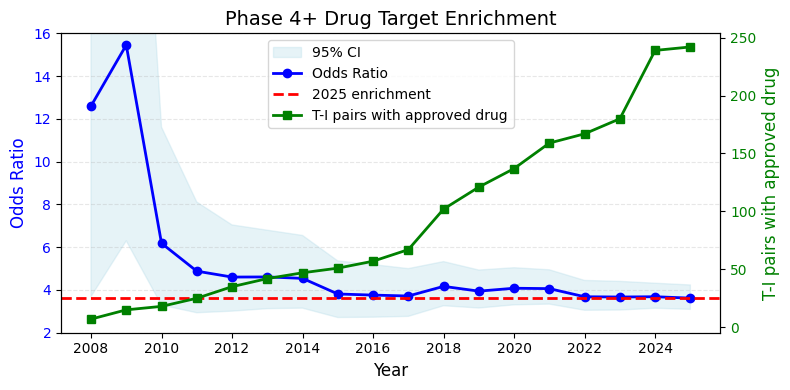

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

years = combined_enrich_4["datasource"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Convert years to numeric for proper ordering
years_numeric = pd.to_numeric(years)
sorted_indices = np.argsort(years_numeric)

# Use .iloc[] for positional indexing instead of direct indexing
years_sorted = years_numeric.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the continuous forest plot
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot odds ratios on left y-axis
ax1.fill_between(
    years_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    years_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=3.619, color="red", linestyle="--", linewidth=2, label="2025 enrichment")

# Customize left y-axis
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_ylim(2, 16)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Create second y-axis for yes_evid-high_clinphase
ax2 = ax1.twinx()
ax2.plot(
    years_sorted,
    yes_evid_high_sorted,
    "s-",
    color="green",
    linewidth=2,
    markersize=6,
    label="T-I pairs with approved drug",
)
ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color="green")
ax2.tick_params(axis="y", labelcolor="green")

# Add title and legends
plt.title("Phase 4+ Drug Target Enrichment", fontsize=14)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", fontsize=10)

# Improve x-axis
plt.xticks(years_sorted[::2], rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


In [24]:
combined_enrich_4


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource
2,4+,12.599462,8.482566e-05,3.686835,43.057648,5.217986,3.335286,8.163433,4.648283e-13,32809,4557,4,7,897,2008,full_chembl
5,4+,15.453632,1.433140e-09,6.297435,37.922542,5.598883,4.203044,7.458282,5.326883e-32,32806,4549,7,15,1921,2009,full_chembl
8,4+,6.182892,1.701029e-07,3.291866,11.612913,3.790788,2.697925,5.326343,1.592828e-14,32792,4546,21,18,3226,2010,full_chembl
11,4+,4.879036,2.102321e-08,2.934577,8.111899,3.314909,2.445820,4.492816,1.114485e-14,32776,4539,37,25,5153,2011,full_chembl
14,4+,4.602782,1.124850e-10,3.009345,7.039939,3.201700,2.467629,4.154143,1.985981e-18,32758,4529,55,35,7505,2012,full_chembl
17,4+,4.608359,1.613344e-12,3.125983,6.793695,3.205108,2.526282,4.066340,8.628457e-22,32747,4522,66,42,9878,2013,full_chembl
20,4+,4.541911,1.181608e-13,3.149960,6.548958,3.177404,2.535127,3.982403,1.080415e-23,32738,4517,75,47,11148,2014,full_chembl
23,4+,3.811477,1.746971e-12,2.711707,5.357273,2.842657,2.272479,3.555896,5.860784e-20,32716,4513,97,51,14458,2015,full_chembl
26,4+,3.759951,1.415303e-13,2.726499,5.185123,2.817932,2.278544,3.485006,1.210880e-21,32703,4507,110,57,16553,2016,full_chembl
29,4+,3.716972,1.757384e-15,2.764551,4.997512,2.797592,2.298073,3.405689,1.164016e-24,32682,4497,131,67,20232,2017,full_chembl
